## Experiments: retrieval evaluation (Campus Search)

**Корпус:** 18 документов (`data/knowledge_base.json`).  
**Benchmark:** 12 запросов — keyword и paraphrase (`artifacts/benchmark_queries.json`).  
**Метрики:** hit@5, MRR@5.

**Предусловие** — матрица экспериментов посчитана скриптом:

```bash
cd project
pip install -e .
python -m aie_rag.scripts.run_experiments
```

**Содержание ноутбука:** EDA, загрузка `artifacts/retrieval_experiment_matrix.csv`, сравнение retriever и chunk_size, графики по per-query CSV.

Протокол и интерпретация: `notebooks/experiments_retrieval.md`.  
**Ядро:** `project/.venv` (Python 3.12).


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("..").resolve()
ARTIFACTS = PROJECT_ROOT / "artifacts"
KB_PATH = PROJECT_ROOT / "data" / "knowledge_base.json"
BENCHMARK = ARTIFACTS / "benchmark_queries.json"
EMBEDDING_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
OVERLAP = 60

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from aie_rag.data.kb import chunk_text, load_kb
print("PROJECT_ROOT:", PROJECT_ROOT)
print("KB exists:", KB_PATH.exists())
print("Benchmark exists:", BENCHMARK.exists())


PROJECT_ROOT: C:\Users\Игорь\Desktop\ИНЖ ИИ\aie_Kombarov_tempate\project
KB exists: True
Benchmark exists: True


In [2]:
# EDA: обзор корпуса
docs = load_kb(KB_PATH)
text_lens = [len(d.text) for d in docs]

eda = pd.DataFrame(
    {
        "metric": [
            "num_documents",
            "text_len_min",
            "text_len_max",
            "text_len_mean",
            "text_len_median",
            "num_chunks_320_60",
        ],
        "value": [
            len(docs),
            min(text_lens),
            max(text_lens),
            round(sum(text_lens) / len(text_lens), 1),
            float(pd.Series(text_lens).median()),
            len(chunk_text(docs=docs, chunk_size=320, overlap=60)),
        ],
    }
)
print("EDA summary:")
print(eda.to_string(index=False))

sample = pd.DataFrame(
    [{"doc_id": d.doc_id, "title": d.title, "text_preview": d.text[:120] + "…"} for d in docs[:3]]
)
sample

EDA summary:
           metric  value
    num_documents   18.0
     text_len_min  287.0
     text_len_max  356.0
    text_len_mean  322.5
  text_len_median  321.5
num_chunks_320_60   27.0


,doc_id,title,text_preview
0,campus_01,Справка об обучении,Справку об обучении можно заказать в деканате ...
1,campus_02,Перевод на другую специальность,Перевод на другую образовательную программу оф...
2,campus_03,Общежитие: заселение,"Заселение в общежитие проходит по спискам, кот..."


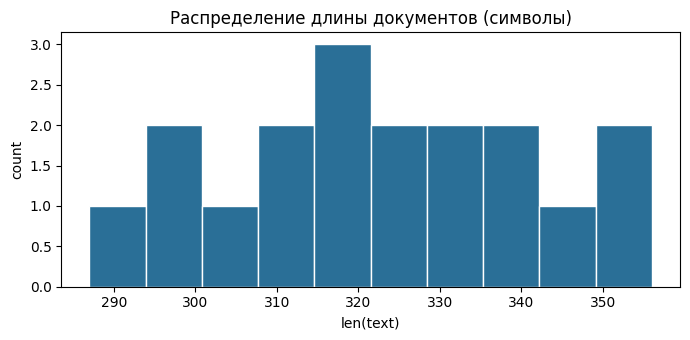

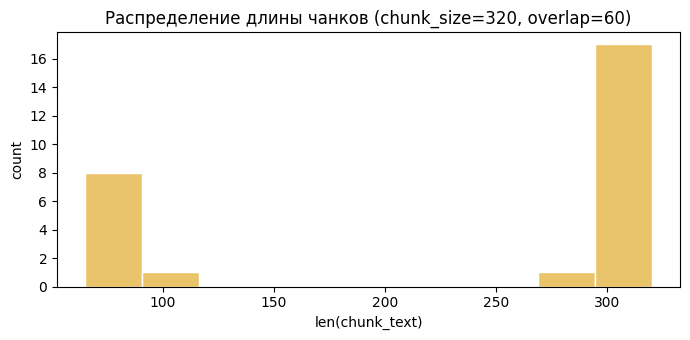

,count,mean,std,min,25%,50%,75%,max
chunk_len,27.0,234.925926,113.422263,65.0,87.5,308.0,320.0,320.0


In [3]:
# Графики EDA: длины документов и чанков
import matplotlib.pyplot as plt

# Длины документов
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(text_lens, bins=10, color="#2a6f97", edgecolor="white")
ax.set_title("Распределение длины документов (символы)")
ax.set_xlabel("len(text)")
ax.set_ylabel("count")
fig.tight_layout()
plt.show()

# Длины чанков при production-чанкинге
chunks_320_60 = chunk_text(docs=docs, chunk_size=320, overlap=60)
chunk_lens = [len(c.text) for c in chunks_320_60]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(chunk_lens, bins=10, color="#e9c46a", edgecolor="white")
ax.set_title("Распределение длины чанков (chunk_size=320, overlap=60)")
ax.set_xlabel("len(chunk_text)")
ax.set_ylabel("count")
fig.tight_layout()
plt.show()

pd.Series(chunk_lens).describe().to_frame("chunk_len").T

In [4]:
MATRIX_PATH = ARTIFACTS / "retrieval_experiment_matrix.csv"
if not MATRIX_PATH.exists():
    raise FileNotFoundError(
        "Нет матрицы экспериментов. В терминале: python -m aie_rag.scripts.run_experiments"
    )

matrix = pd.read_csv(MATRIX_PATH)
print(f"Конфигураций: {len(matrix)}, запросов в benchmark: {int(matrix['num_queries'].iloc[0])}")
matrix.sort_values(["chunk_size", "chunk_overlap", "retriever"])


Конфигураций: 12, запросов в benchmark: 12


,chunk_size,chunk_overlap,retriever,hit@5,mrr@5,num_queries
1,200,40,bm25,0.833333,0.833333,12
0,200,40,dense,1.000000,0.944444,12
2,200,40,hybrid,1.000000,0.891667,12
4,200,60,bm25,0.833333,0.833333,12
3,200,60,dense,1.000000,0.902778,12
5,200,60,hybrid,0.916667,0.875000,12
7,320,40,bm25,0.833333,0.791667,12
6,320,40,dense,1.000000,0.958333,12
8,320,40,hybrid,1.000000,0.902778,12
10,320,60,bm25,0.833333,0.791667,12


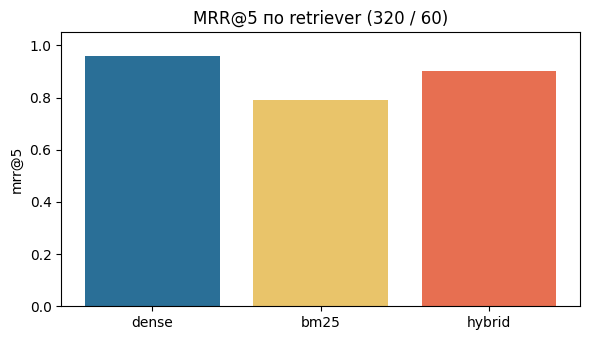

In [5]:
# Сводка при production-параметрах overlap=60
prod = matrix[matrix["chunk_overlap"] == 60].copy()
prod.pivot_table(index=["chunk_size", "retriever"], values=["hit@5", "mrr@5"], aggfunc="first")

# График: MRR@5 по retriever (chunk=320, overlap=60)
import matplotlib.pyplot as plt

sub = matrix[(matrix.chunk_size == 320) & (matrix.chunk_overlap == 60)]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(sub["retriever"], sub["mrr@5"], color=["#2a6f97", "#e9c46a", "#e76f51"])
ax.set_ylim(0, 1.05)
ax.set_title("MRR@5 по retriever (320 / 60)")
ax.set_ylabel("mrr@5")
fig.tight_layout()
plt.show()

In [6]:
# Разбивка по типу запроса: dense vs BM25 (320/60)
per_dense = pd.read_csv(ARTIFACTS / "retrieval_per_query_dense_320_60.csv")
per_bm25 = pd.read_csv(ARTIFACTS / "retrieval_per_query_bm25_320_60.csv")

by_type = (
    pd.concat(
        [
            per_dense.assign(retriever="dense"),
            per_bm25.assign(retriever="bm25"),
        ]
    )
    .groupby(["retriever", "query_type"])[["hit@5", "mrr@5"]]
    .mean()
    .round(3)
)
print("Средние метрики по типу запроса:")
by_type

# Примеры ошибок BM25 (hit@5=0)
failed = per_bm25[per_bm25["hit@5"] == 0][["query", "query_type", "retrieved_doc_ids"]]
if len(failed):
    print("\nЗапросы без попадания (BM25):")
    print(failed.to_string(index=False))
else:
    print("\nBM25: все запросы с hit@5=1")

Средние метрики по типу запроса:

Запросы без попадания (BM25):
                                        query query_type                                                 retrieved_doc_ids
 во сколько нельзя заходить в общежитие ночью paraphrase ['campus_03', 'campus_17', 'campus_12', 'campus_14', 'campus_17']
прервать обучение из-за здоровья как оформить paraphrase ['campus_01', 'campus_02', 'campus_02', 'campus_03', 'campus_04']


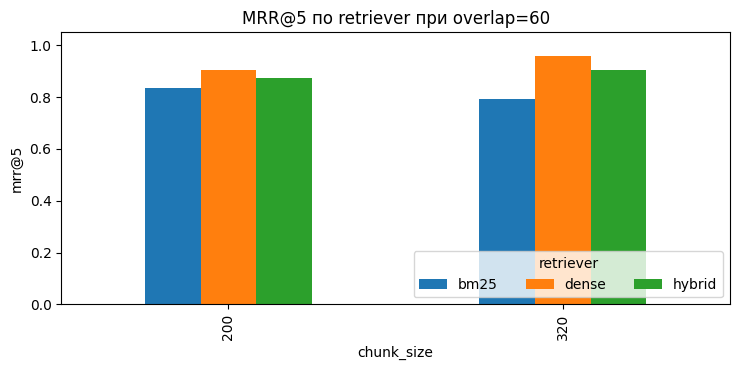

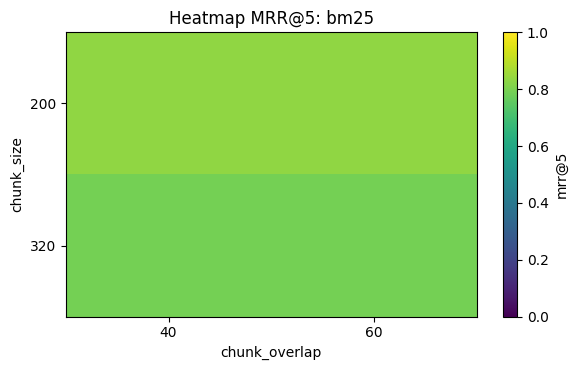

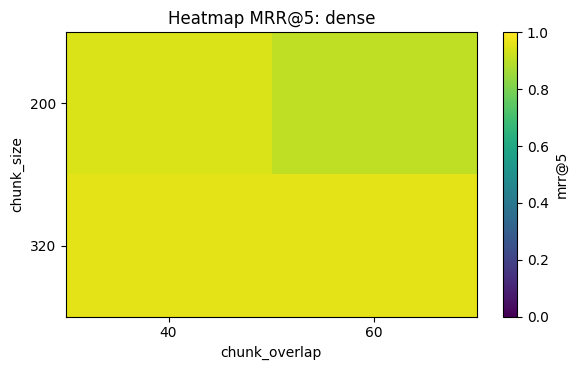

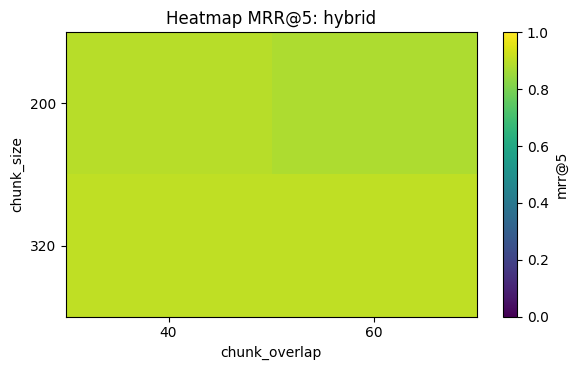

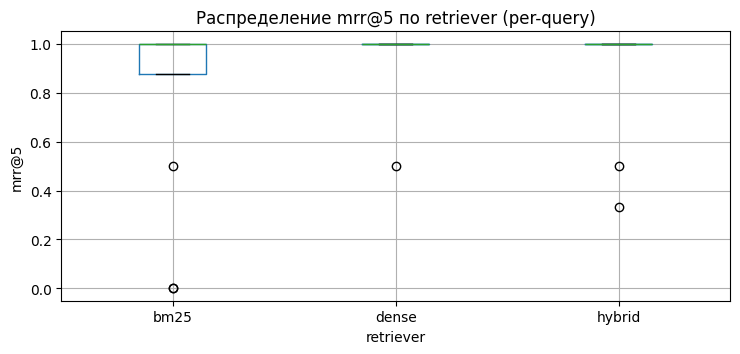

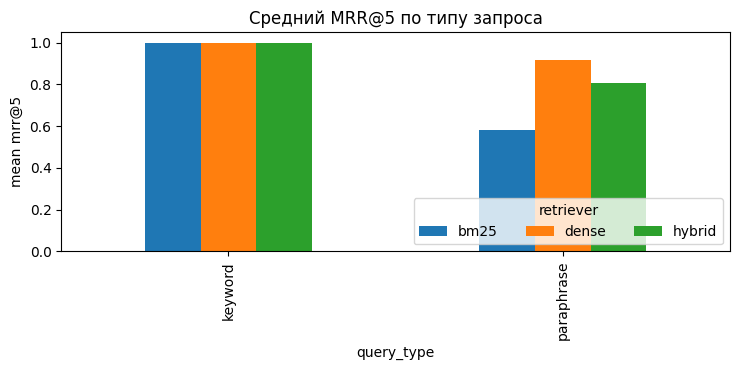

In [7]:
# Дополнительные графики по экспериментам (если есть полная матрица)
import matplotlib.pyplot as plt

# 1) Сравнение retriever'ов при фиксированном overlap, если колонка существует
if "chunk_overlap" in matrix.columns:
    overlap_val = 60
    sub = matrix[matrix["chunk_overlap"] == overlap_val].copy()

    if {"chunk_size", "retriever", "mrr@5"}.issubset(sub.columns):
        pivot = sub.pivot_table(index="chunk_size", columns="retriever", values="mrr@5", aggfunc="first")
        fig, ax = plt.subplots(figsize=(7.5, 3.8))
        pivot.sort_index().plot(kind="bar", ax=ax)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"MRR@5 по retriever при overlap={overlap_val}")
        ax.set_xlabel("chunk_size")
        ax.set_ylabel("mrr@5")
        ax.legend(title="retriever", ncols=3, loc="lower right")
        fig.tight_layout()
        plt.show()

# 2) Heatmap MRR@5 по chunk_size × overlap для каждого retriever (если матрица полная)
if {"chunk_size", "chunk_overlap", "retriever", "mrr@5"}.issubset(matrix.columns):
    for retr in sorted(matrix["retriever"].unique()):
        sub = matrix[matrix["retriever"] == retr]
        hm = sub.pivot_table(index="chunk_size", columns="chunk_overlap", values="mrr@5", aggfunc="first")
        if hm.empty:
            continue
        fig, ax = plt.subplots(figsize=(6, 3.8))
        im = ax.imshow(hm.sort_index().values, aspect="auto", vmin=0, vmax=1, cmap="viridis")
        ax.set_title(f"Heatmap MRR@5: {retr}")
        ax.set_xlabel("chunk_overlap")
        ax.set_ylabel("chunk_size")
        ax.set_xticks(range(len(hm.columns)))
        ax.set_xticklabels([str(x) for x in hm.columns])
        ax.set_yticks(range(len(hm.index)))
        ax.set_yticklabels([str(x) for x in hm.sort_index().index])
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("mrr@5")
        fig.tight_layout()
        plt.show()

# 3) Per-query: сравнение dense/bm25/hybrid по mrr@5 (если есть файлы)
per_files = {
    "dense": ARTIFACTS / "retrieval_per_query_dense_320_60.csv",
    "bm25": ARTIFACTS / "retrieval_per_query_bm25_320_60.csv",
    "hybrid": ARTIFACTS / "retrieval_per_query_hybrid_320_60.csv",
}

available = {k: p for k, p in per_files.items() if p.exists()}
if available:
    per_all = []
    for retr, path in available.items():
        df = pd.read_csv(path)
        df["retriever"] = retr
        per_all.append(df)
    per_all = pd.concat(per_all, ignore_index=True)

    # “самые сложные запросы” по dense (минимальный mrr@5)
    if "dense" in available and {"query", "mrr@5"}.issubset(per_all.columns):
        hard = (
            per_all[per_all["retriever"] == "dense"]["mrr@5"]
            .sort_values()
            .head(5)
            .index
        )

    # boxplot mrr@5 по retriever
    if {"retriever", "mrr@5"}.issubset(per_all.columns):
        fig, ax = plt.subplots(figsize=(7.5, 3.8))
        per_all.boxplot(column="mrr@5", by="retriever", ax=ax)
        ax.set_title("Распределение mrr@5 по retriever (per-query)")
        ax.set_xlabel("retriever")
        ax.set_ylabel("mrr@5")
        plt.suptitle("")
        fig.tight_layout()
        plt.show()

    # bar: средний mrr@5 по query_type
    if {"retriever", "query_type", "mrr@5"}.issubset(per_all.columns):
        by_type = per_all.groupby(["retriever", "query_type"])["mrr@5"].mean().unstack(0)
        fig, ax = plt.subplots(figsize=(7.5, 3.8))
        by_type.plot(kind="bar", ax=ax)
        ax.set_ylim(0, 1.05)
        ax.set_title("Средний MRR@5 по типу запроса")
        ax.set_xlabel("query_type")
        ax.set_ylabel("mean mrr@5")
        ax.legend(title="retriever", ncols=3, loc="lower right")
        fig.tight_layout()
        plt.show()
else:
    print("Per-query CSV не найдены. Запустите: python -m aie_rag.scripts.run_experiments")

### Вывод

1. **Матрица 12 конфигураций** — `artifacts/retrieval_experiment_matrix.csv`; графики — `artifacts/figures/`.
2. **chunk_size=320**, overlap=60, **dense** — лучший баланс hit@5 и mrr@5 на расширенном benchmark.
3. **BM25** слабее на paraphrase-запросах → обоснование семантического retriever в API.
4. Продакшн: `build_index` → `uvicorn` → проверка `client.py` или `/docs`.